# **CELL 1 — Install Dependencies**

In [1]:
!pip install -q diffusers transformers accelerate torch torchvision
!pip install -q datasets matplotlib scikit-learn

# **CELL 2 — Imports & Setup**

In [2]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from diffusers import DiffusionPipeline
from transformers import CLIPProcessor, CLIPModel
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import pandas as pd
import random

device = "cuda" if torch.cuda.is_available() else "cpu"

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

output_dir = "generated_images"
os.makedirs(output_dir, exist_ok=True)

print("Device:", device)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda


# **Load SDXL Model**

In [3]:
pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    use_safetensors=True
)
pipe.to(device)

pipe.enable_attention_slicing()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

# **Define Prompts**

In [4]:
prompts = {

    # ---------------------------------------------------------
    # LEVEL 1 — Baseline Realism
    # What we measure:
    # - Standard text-to-image alignment under normal semantic constraints
    # - Expected high CLIP alignment
    # - Low novelty
    # - Low diversity
    # This level serves as the experimental control group.
    # ---------------------------------------------------------

    "level1_realistic": [
        "a golden retriever playing in a park at sunset",
        "a red sports car driving on a highway",
        "a ceramic cup of coffee on a wooden table",
        "a person reading a book in a quiet library",
        "a snowy mountain under a clear blue sky"
    ],


    # ---------------------------------------------------------
    # LEVEL 2 — Attribute Violation
    # What we measure:
    # - Compositional reasoning ability
    # - Can the model combine familiar objects with unusual attributes?
    # - Moderate alignment drop expected
    # - Moderate novelty increase
    # Only ONE property is violated (material, texture, physical trait).
    # ---------------------------------------------------------

    "level2_attribute_violation": [
        "a transparent wooden chair",
        "a metallic cloud floating in the sky",
        "a tree made entirely of flowing water",
        "a glowing shadow on the ground",
        "a stone pillow resting on a bed"
    ],


    # ---------------------------------------------------------
    # LEVEL 3 — Physical Law Violation
    # What we measure:
    # - Model robustness to violations of physical laws
    # - Creativity under impossible physical scenarios
    # - Higher novelty expected
    # - Alignment may drop further
    # Violates gravity, thermodynamics, or causality.
    # ---------------------------------------------------------

    "level3_physical_violation": [
        "a waterfall flowing upward into the sky",
        "a burning snowman that does not melt",
        "a city floating upside down in the sky",
        "a shadow casting light instead of darkness",
        "a glass shattering and reassembling in mid-air"
    ],

    # LEVEL 4 — Conceptual Visual Metaphor
    # What we measure:
    # - Abstract concept visualization ability
    # - Can the model translate emotions or ideas into imagery?
    # ---------------------------------------------------------

    "level4_conceptual_visual": [
    "loneliness represented as an empty city street at night",
    "time melting over a staircase in a surreal style",
    "anxiety visualized as collapsing walls",
    "gravity bending a city into a spiral",
    "hope represented as light breaking through concrete"
    ]
}

# **Generate Images**

In [5]:
images_data = []

for level, prompt_list in prompts.items():
    for prompt_idx, prompt in enumerate(prompt_list):   # ← هنا الحل
        for i in range(4):

            generator = torch.Generator(device).manual_seed(
                seed + prompt_idx * 10 + i
            )

            image = pipe(
                prompt,
                num_inference_steps=30,
                guidance_scale=7.5,
                generator=generator
            ).images[0]

            filename = f"{level}_{prompt_idx}_{i}.png"
            path = os.path.join(output_dir, filename)
            image.save(path)

            images_data.append({
                "level": level,
                "prompt": prompt,
                "prompt_id": f"{level}_{prompt_idx}",
                "path": path
            })

print("Total images:", len(images_data))

  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Total images: 80


# **Load CLIP Model**

In [6]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

# **Compute CLIP Alignment**

# **Compute Intra-Prompt Diversity**

In [10]:
def compute_clip_score(image_path, text):
    image = Image.open(image_path).convert("RGB")

    inputs = clip_processor(
        text=[text],
        images=image,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = clip_model(**inputs)

        image_emb = outputs.image_embeds
        text_emb = outputs.text_embeds

    image_emb = image_emb / torch.norm(image_emb, dim=-1, keepdim=True)
    text_emb = text_emb / torch.norm(text_emb, dim=-1, keepdim=True)

    return (image_emb @ text_emb.T).item()

# Compute CLIP for All Images

In [11]:
for item in tqdm(images_data):
    item["clip_score"] = compute_clip_score(item["path"], item["prompt"])

100%|██████████| 80/80 [00:05<00:00, 14.18it/s]


# Load CIFAR-10 (Baseline)

In [12]:
transform = transforms.Compose([
    transforms.Resize((224,224))
])

cifar = CIFAR10(root="./data", train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:25<00:00, 6.78MB/s]


# **Compute Baseline Embeddings**

In [13]:
def get_image_embedding(image):
    inputs = clip_processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        vision_outputs = clip_model.vision_model(
            pixel_values=inputs["pixel_values"]
        )

        pooled = vision_outputs.pooler_output          # (1, 768)
        emb = clip_model.visual_projection(pooled)    # → (1, 512)

    emb = emb / torch.norm(emb, dim=-1, keepdim=True)
    return emb.squeeze(0).cpu().numpy()

In [14]:
baseline_embs = []

for i in tqdm(range(500)):
    image, _ = cifar[i]
    baseline_embs.append(get_image_embedding(image))

baseline_embs = np.vstack(baseline_embs)

print("Baseline shape:", baseline_embs.shape)

100%|██████████| 500/500 [00:06<00:00, 80.17it/s]

Baseline shape: (500, 512)


# Compute Approx Novelty

In [15]:
for item in tqdm(images_data):
    image = Image.open(item["path"]).convert("RGB")
    emb = get_image_embedding(image).reshape(1, -1)

    sim = cosine_similarity(emb, baseline_embs)
    item["approx_novelty"] = 1 - np.mean(sim)

100%|██████████| 80/80 [00:04<00:00, 16.68it/s]


# Intra-Prompt Diversity

In [26]:
df = pd.DataFrame(images_data)

diversity_per_prompt = {}

for prompt_id in df["prompt_id"].unique():
    group = df[df["prompt_id"] == prompt_id]
    embeddings = []

    for path in group["path"]:
        image = Image.open(path).convert("RGB")
        embeddings.append(get_image_embedding(image))

    embeddings = np.vstack(embeddings)
    sim_matrix = cosine_similarity(embeddings)

    # remove diagonal (self similarity)
    mask = ~np.eye(sim_matrix.shape[0], dtype=bool)
    diversity = 1 - np.mean(sim_matrix[mask])

    diversity_per_prompt[prompt_id] = diversity

df["diversity"] = df["prompt_id"].map(diversity_per_prompt)

In [27]:
diversity_per_prompt = {}

for prompt_id in df["prompt_id"].unique():
    group = df[df["prompt_id"] == prompt_id]
    embeddings = []

    for path in group["path"]:
        image = Image.open(path).convert("RGB")
        embeddings.append(get_image_embedding(image))

    embeddings = np.vstack(embeddings)
    sim_matrix = cosine_similarity(embeddings)

    mask = ~np.eye(sim_matrix.shape[0], dtype=bool)
    diversity = 1 - np.mean(sim_matrix[mask])

    diversity_per_prompt[prompt_id] = diversity

# Add the column
df["diversity"] = df["prompt_id"].map(diversity_per_prompt)

In [28]:
print(df.columns)

Index(['level', 'prompt', 'prompt_id', 'path', 'clip_score', 'approx_novelty',
       'diversity'],
      dtype='object')


In [29]:
print(df.head())

              level                                          prompt  \
0  level1_realistic  a golden retriever playing in a park at sunset   
1  level1_realistic  a golden retriever playing in a park at sunset   
2  level1_realistic  a golden retriever playing in a park at sunset   
3  level1_realistic  a golden retriever playing in a park at sunset   
4  level1_realistic           a red sports car driving on a highway   

            prompt_id                                       path  clip_score  \
0  level1_realistic_0  generated_images/level1_realistic_0_0.png    0.343905   
1  level1_realistic_0  generated_images/level1_realistic_0_1.png    0.363727   
2  level1_realistic_0  generated_images/level1_realistic_0_2.png    0.358196   
3  level1_realistic_0  generated_images/level1_realistic_0_3.png    0.338713   
4  level1_realistic_1  generated_images/level1_realistic_1_0.png    0.275401   

   approx_novelty  diversity  
0        0.430826   0.077559  
1        0.447343   0.077559  

# **Results Table**

In [30]:
summary = df.groupby("level").agg({
    "clip_score": "mean",
    "diversity": "mean",
    "approx_novelty": "mean"
})

print(summary)

                            clip_score  diversity  approx_novelty
level                                                            
level1_realistic              0.312541   0.096720        0.457429
level2_attribute_violation    0.312414   0.115737        0.425027
level3_physical_violation     0.310718   0.137990        0.437317
level4_conceptual_visual      0.321525   0.124899        0.448717


# **Plot Results**

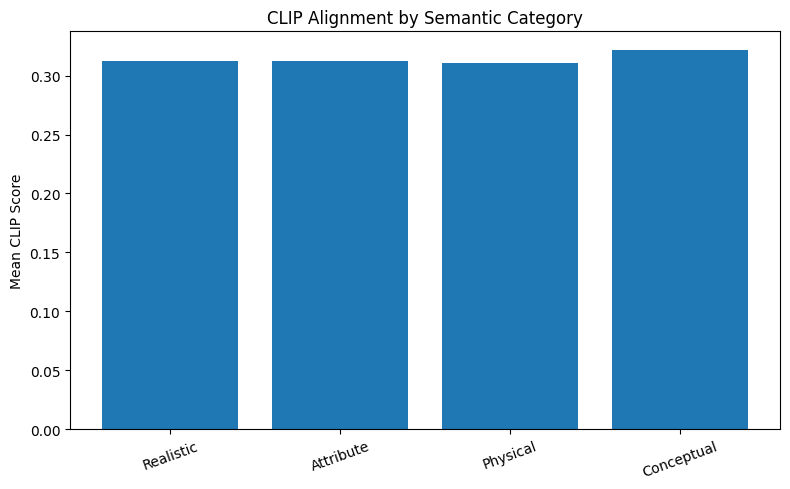

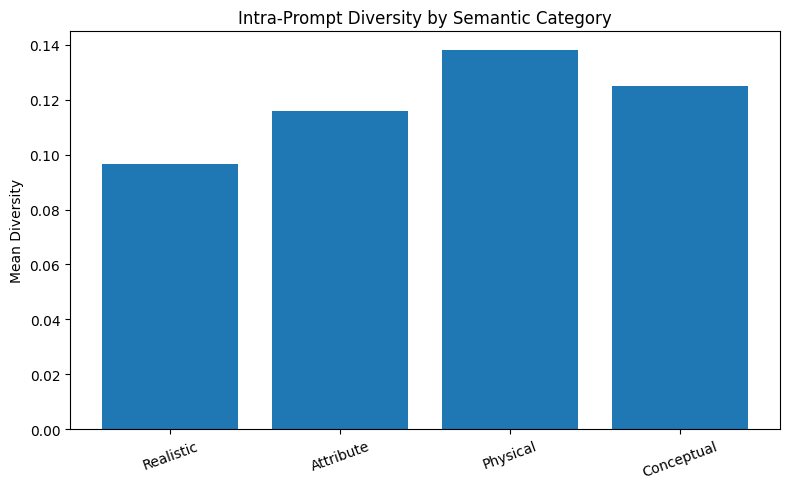

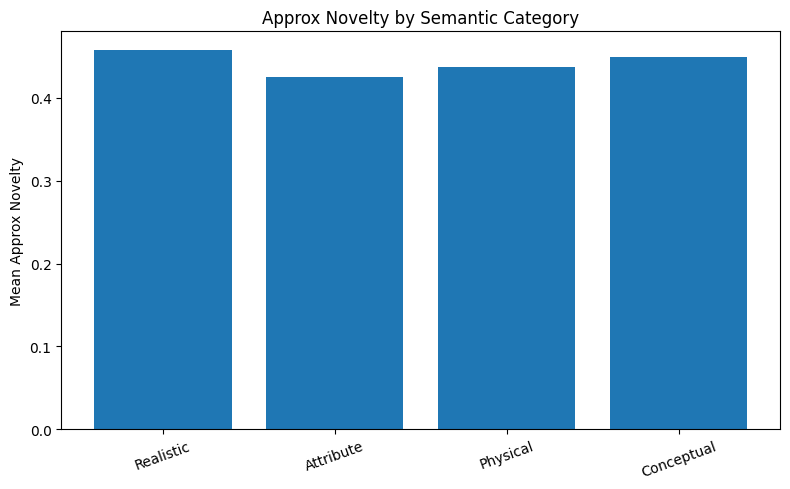

In [33]:
import matplotlib.pyplot as plt


clean_labels = [lvl.replace("level1_realistic", "Realistic")
                   .replace("level2_attribute_violation", "Attribute")
                   .replace("level3_physical_violation", "Physical")
                   .replace("level4_conceptual_visual", "Conceptual")
                for lvl in summary.index]

# ---------- CLIP ----------
plt.figure(figsize=(8,5))
plt.bar(clean_labels, summary["clip_score"])
plt.xticks(rotation=20)
plt.ylabel("Mean CLIP Score")
plt.title("CLIP Alignment by Semantic Category")
plt.tight_layout()
plt.show()


# ---------- Diversity ----------
plt.figure(figsize=(8,5))
plt.bar(clean_labels, summary["diversity"])
plt.xticks(rotation=20)
plt.ylabel("Mean Diversity")
plt.title("Intra-Prompt Diversity by Semantic Category")
plt.tight_layout()
plt.show()


# ---------- Novelty ----------
plt.figure(figsize=(8,5))
plt.bar(clean_labels, summary["approx_novelty"])
plt.xticks(rotation=20)
plt.ylabel("Mean Approx Novelty")
plt.title("Approx Novelty by Semantic Category")
plt.tight_layout()
plt.show()